In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/yachna26/aqi-weather-mumbai-model/mumbai_final_dataset.csv")

In [4]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
df.head()

,time,us_aqi,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure
0,2025-06-13 00:00:00,57,17.1,30.7,7.6,50.0,10.4,247.0,29.0,86,0.2,13.2,299,1001.5
1,2025-06-13 01:00:00,57,16.2,31.1,6.3,51.0,8.6,188.0,28.9,86,0.1,12.9,300,1000.7
2,2025-06-13 02:00:00,58,23.1,51.0,5.5,51.0,7.2,147.0,28.8,87,0.1,11.3,303,1000.6
3,2025-06-13 03:00:00,59,17.8,38.6,5.5,51.0,6.7,134.0,28.5,88,0.1,12.9,310,1000.1
4,2025-06-13 04:00:00,59,17.8,39.8,6.0,52.0,6.7,137.0,28.2,90,0.1,13.2,323,1000.3


In [6]:
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
df['week_of_year'] = df['time'].dt.isocalendar().week.astype(int)

In [7]:
df[['time','hour','day_of_week','month','week_of_year']].head()

,time,hour,day_of_week,month,week_of_year
0,2025-06-13 00:00:00,0,4,6,24
1,2025-06-13 01:00:00,1,4,6,24
2,2025-06-13 02:00:00,2,4,6,24
3,2025-06-13 03:00:00,3,4,6,24
4,2025-06-13 04:00:00,4,4,6,24


In [9]:
lags = [1, 3, 6, 12, 24, 48]

for lag in lags:
    df[f'aqi_lag_{lag}'] = (df['us_aqi'].shift(lag))

In [10]:
df[
    [
        'us_aqi',
        'aqi_lag_1',
        'aqi_lag_24'
    ]
].head(30)

,us_aqi,aqi_lag_1,aqi_lag_24
0,57,NaN,NaN
1,57,57.0,NaN
2,58,57.0,NaN
3,59,58.0,NaN
4,59,59.0,NaN
5,59,59.0,NaN
6,59,59.0,NaN
7,59,59.0,NaN
8,60,59.0,NaN
9,60,60.0,NaN


In [11]:
print(df.shape)

print(
    df[
        [
            'time',
            'us_aqi',
            'hour',
            'aqi_lag_1',
            'aqi_lag_24',
            'aqi_lag_48'
        ]
    ].head(30)
)

(8784, 24)
                  time  us_aqi  hour  aqi_lag_1  aqi_lag_24  aqi_lag_48
0  2025-06-13 00:00:00      57     0        NaN         NaN         NaN
1  2025-06-13 01:00:00      57     1       57.0         NaN         NaN
2  2025-06-13 02:00:00      58     2       57.0         NaN         NaN
3  2025-06-13 03:00:00      59     3       58.0         NaN         NaN
4  2025-06-13 04:00:00      59     4       59.0         NaN         NaN
5  2025-06-13 05:00:00      59     5       59.0         NaN         NaN
6  2025-06-13 06:00:00      59     6       59.0         NaN         NaN
7  2025-06-13 07:00:00      59     7       59.0         NaN         NaN
8  2025-06-13 08:00:00      60     8       59.0         NaN         NaN
9  2025-06-13 09:00:00      60     9       60.0         NaN         NaN
10 2025-06-13 10:00:00      60    10       60.0         NaN         NaN
11 2025-06-13 11:00:00      61    11       60.0         NaN         NaN
12 2025-06-13 12:00:00      61    12       61.0      

In [12]:
df['aqi_roll_mean_24'] = df['us_aqi'].rolling(24).mean()

df['aqi_roll_std_24'] = df['us_aqi'].rolling(24).std()

df['pm25_roll_mean_24'] = df['pm2_5'].rolling(24).mean()

In [13]:
print(
    df[
        [
            'time',
            'us_aqi',
            'aqi_roll_mean_24',
            'aqi_roll_std_24',
            'pm2_5',
            'pm25_roll_mean_24'
        ]
    ].head(30)
)

                  time  us_aqi  aqi_roll_mean_24  aqi_roll_std_24  pm2_5  \
0  2025-06-13 00:00:00      57               NaN              NaN   17.1   
1  2025-06-13 01:00:00      57               NaN              NaN   16.2   
2  2025-06-13 02:00:00      58               NaN              NaN   23.1   
3  2025-06-13 03:00:00      59               NaN              NaN   17.8   
4  2025-06-13 04:00:00      59               NaN              NaN   17.8   
5  2025-06-13 05:00:00      59               NaN              NaN   16.1   
6  2025-06-13 06:00:00      59               NaN              NaN   16.3   
7  2025-06-13 07:00:00      59               NaN              NaN   17.8   
8  2025-06-13 08:00:00      60               NaN              NaN   18.9   
9  2025-06-13 09:00:00      60               NaN              NaN   19.0   
10 2025-06-13 10:00:00      60               NaN              NaN   20.5   
11 2025-06-13 11:00:00      61               NaN              NaN   22.2   
12 2025-06-1

In [14]:
df['target_24h'] = df['us_aqi'].shift(-24)

In [15]:
df = df.dropna().reset_index(drop=True)

print(df.shape)

(8712, 28)


In [16]:
X = df.drop(columns=['time', 'target_24h'])
y = df['target_24h']

print(X.shape)
print(y.shape)

(8712, 26)
(8712,)


In [17]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(6969, 26)
(1743, 26)


In [18]:
baseline_pred = X_test['us_aqi']

In [19]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

baseline_mae = mean_absolute_error(y_test,baseline_pred)

baseline_rmse = (mean_squared_error(y_test,baseline_pred) ** 0.5)

baseline_r2 = r2_score(y_test,baseline_pred)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2  :", baseline_r2)

Baseline MAE : 10.44750430292599
Baseline RMSE: 15.882493059077913
Baseline R2  : 0.565113761212249


In [21]:
import xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [22]:
xgb_pred = xgb_model.predict(X_test)

In [23]:
xgb_mae = mean_absolute_error(y_test,xgb_pred)

xgb_rmse = (mean_squared_error(y_test,xgb_pred) ** 0.5)

xgb_r2 = r2_score(y_test,xgb_pred)

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2  :", xgb_r2)

XGBoost MAE : 9.862150683597251
XGBoost RMSE: 14.796350324041686
XGBoost R2  : 0.6225603441568974


In [24]:
import pandas as pd

feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': xgb_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

print(feature_importance.head(15))

                 Feature  Importance
17             aqi_lag_1    0.462251
0                 us_aqi    0.317157
1                  pm2_5    0.028536
13                  hour    0.019155
12      surface_pressure    0.014066
25     pm25_roll_mean_24    0.011816
16          week_of_year    0.010550
8   relative_humidity_2m    0.009858
9          precipitation    0.009840
19             aqi_lag_6    0.009812
23      aqi_roll_mean_24    0.009647
15                 month    0.009468
2                   pm10    0.009219
20            aqi_lag_12    0.008700
11    wind_direction_10m    0.007988


In [25]:
comparison_df = pd.DataFrame({'Actual': y_test.values,'Predicted': xgb_pred})

comparison_df['Error'] = (comparison_df['Actual'] -comparison_df['Predicted'])

comparison_df['Absolute_Error'] = (comparison_df['Error'].abs())

comparison_df.head(10)

,Actual,Predicted,Error,Absolute_Error
0,65.0,69.631157,-4.631157,4.631157
1,65.0,69.727173,-4.727173,4.727173
2,64.0,69.436340,-5.436340,5.436340
3,64.0,69.173103,-5.173103,5.173103
4,64.0,67.643921,-3.643921,3.643921
5,70.0,64.644020,5.355980,5.355980
6,87.0,63.857098,23.142902,23.142902
7,102.0,63.119534,38.880466,38.880466
8,112.0,65.905678,46.094322,46.094322
9,111.0,71.023178,39.976822,39.976822


In [26]:
comparison_df.sort_values('Absolute_Error').head(10)

,Actual,Predicted,Error,Absolute_Error
615,87.0,86.998840,0.001160,0.001160
1496,77.0,76.983948,0.016052,0.016052
1670,76.0,76.021667,-0.021667,0.021667
940,88.0,87.975174,0.024826,0.024826
903,82.0,81.966270,0.033730,0.033730
1023,77.0,76.951973,0.048027,0.048027
687,71.0,71.051804,-0.051804,0.051804
1097,65.0,65.066788,-0.066788,0.066788
1217,60.0,59.919567,0.080433,0.080433
1398,65.0,64.904427,0.095573,0.095573


In [27]:
comparison_df.sort_values('Absolute_Error',ascending=False).head(10)

,Actual,Predicted,Error,Absolute_Error
295,198.0,116.461136,81.538864,81.538864
297,202.0,120.508171,81.491829,81.491829
298,187.0,112.816032,74.183968,74.183968
294,176.0,102.819778,73.180222,73.180222
296,204.0,133.636856,70.363144,70.363144
944,181.0,110.688545,70.311455,70.311455
225,184.0,113.980377,70.019623,70.019623
465,189.0,119.151917,69.848083,69.848083
224,186.0,117.469292,68.530708,68.530708
222,167.0,99.188034,67.811966,67.811966


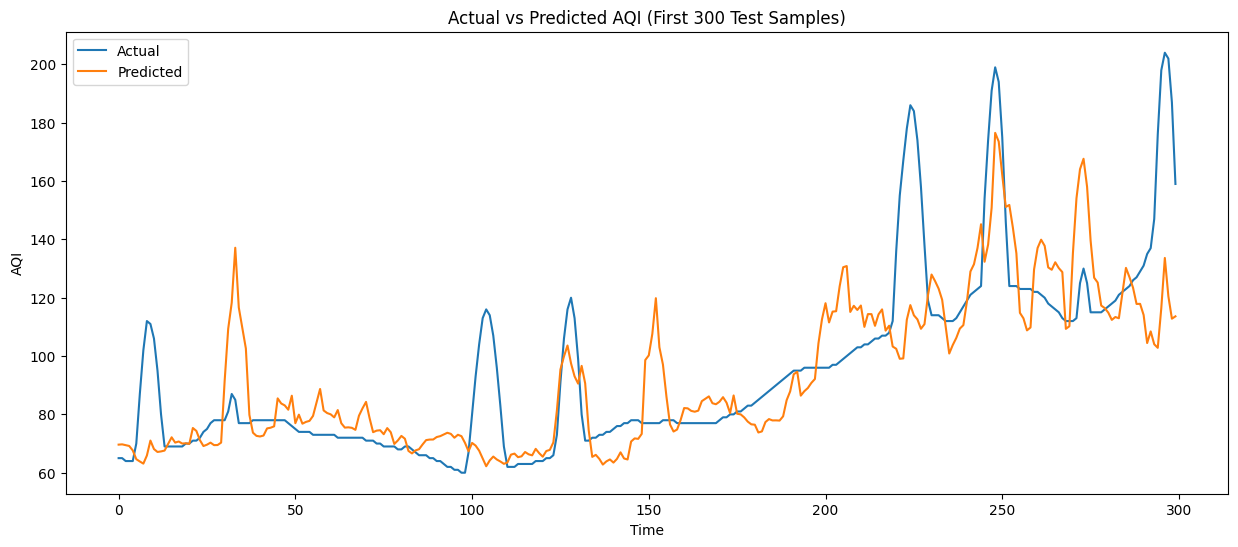

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.values[:300],label='Actual')
plt.plot(xgb_pred[:300],label='Predicted')
plt.legend()
plt.title('Actual vs Predicted AQI (First 300 Test Samples)')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.show()

In [29]:
df.iloc[split_index + 290 : split_index + 300][
    [
        'time',
        'us_aqi',
        'pm2_5',
        'precipitation',
        'wind_speed_10m',
        'relative_humidity_2m',
        'surface_pressure'
    ]
]

,time,us_aqi,pm2_5,precipitation,wind_speed_10m,relative_humidity_2m,surface_pressure
7259,2026-04-13 11:00:00,115,50.6,0.0,9.2,62,1010.3
7260,2026-04-13 12:00:00,113,48.0,0.0,11.1,60,1009.9
7261,2026-04-13 13:00:00,112,44.6,0.0,12.4,59,1009.2
7262,2026-04-13 14:00:00,112,42.0,0.0,13.2,60,1008.4
7263,2026-04-13 15:00:00,112,40.2,0.0,13.8,65,1007.9
7264,2026-04-13 16:00:00,113,39.0,0.0,13.0,67,1007.8
7265,2026-04-13 17:00:00,125,41.9,0.0,11.9,73,1007.9
7266,2026-04-13 18:00:00,130,41.1,0.0,9.0,77,1008.2
7267,2026-04-13 19:00:00,125,40.4,0.0,6.7,80,1008.6
7268,2026-04-13 20:00:00,115,40.5,0.0,5.6,82,1009.3


In [30]:
print(df['target_24h'].describe())

print(df['target_24h'].quantile([
    0.5,
    0.75,
    0.90,
    0.95,
    0.99
]))

count    8712.000000
mean      106.424013
std        51.422184
min        36.000000
25%        65.000000
50%        82.000000
75%       150.000000
max       297.000000
Name: target_24h, dtype: float64
0.50     82.0
0.75    150.0
0.90    180.0
0.95    212.0
0.99    242.0
Name: target_24h, dtype: float64


In [31]:
worst_indices = comparison_df.sort_values('Absolute_Error',ascending=False).head(10).index

actual_df_indices = split_index + worst_indices

df.iloc[actual_df_indices][[
    'time',
    'us_aqi',
    'target_24h',
    'pm2_5',
    'precipitation',
    'wind_speed_10m',
    'relative_humidity_2m',
    'surface_pressure'
]]

,time,us_aqi,target_24h,pm2_5,precipitation,wind_speed_10m,relative_humidity_2m,surface_pressure
7264,2026-04-13 16:00:00,113,198.0,39.0,0.0,13.0,67,1007.8
7266,2026-04-13 18:00:00,130,202.0,41.1,0.0,9.0,77,1008.2
7267,2026-04-13 19:00:00,125,187.0,40.4,0.0,6.7,80,1008.6
7263,2026-04-13 15:00:00,112,176.0,40.2,0.0,13.8,65,1007.9
7265,2026-04-13 17:00:00,125,204.0,41.9,0.0,11.9,73,1007.9
7913,2026-05-10 17:00:00,163,181.0,28.5,0.0,16.9,52,1002.5
7194,2026-04-10 18:00:00,96,184.0,32.8,0.0,14.5,63,1008.6
7434,2026-04-20 18:00:00,126,189.0,23.9,0.0,11.0,70,1005.4
7193,2026-04-10 17:00:00,96,186.0,32.4,0.0,16.0,52,1008.5
7191,2026-04-10 15:00:00,96,167.0,31.4,0.0,15.4,51,1008.7


In [34]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)

df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)

df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [35]:
df[['hour','hour_sin','hour_cos']].head(25)

,hour,hour_sin,hour_cos
0,0,0.000000e+00,1.000000e+00
1,1,2.588190e-01,9.659258e-01
2,2,5.000000e-01,8.660254e-01
3,3,7.071068e-01,7.071068e-01
4,4,8.660254e-01,5.000000e-01
5,5,9.659258e-01,2.588190e-01
6,6,1.000000e+00,6.123234e-17
7,7,9.659258e-01,-2.588190e-01
8,8,8.660254e-01,-5.000000e-01
9,9,7.071068e-01,-7.071068e-01


In [41]:
X = df.drop(columns=['time', 'target_24h'])
y = df['target_24h']

In [42]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [43]:
from xgboost import XGBRegressor

xgb_model_cycle = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_cycle.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
cycle_pred = xgb_model_cycle.predict(X_test)

In [45]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

cycle_mae = mean_absolute_error(y_test,cycle_pred)

cycle_rmse = mean_squared_error(y_test,cycle_pred) ** 0.5

cycle_r2 = r2_score(y_test,cycle_pred)

print("MAE :", cycle_mae)
print("RMSE:", cycle_rmse)
print("R2  :", cycle_r2)

MAE : 9.82401410670234
RMSE: 14.649228921670003
R2  : 0.6300288594566232


### Observation: Cyclic encoding had no effect
Cyclic (sin/cos) encoding of hour/month gave identical metrics to raw integer 
encoding. This is expected for tree-based models like XGBoost — they can already 
capture periodicity via splits on raw hour/month values. Cyclic encoding matters 
more for linear models or neural networks. Keeping raw temporal features going forward.

In [46]:
horizons = [6, 12, 24, 48]
results = []

for h in horizons:
    df_h = df.copy()
    df_h['target'] = df_h['us_aqi'].shift(-h)
    df_h = df_h.dropna().reset_index(drop=True)
    
    X_h = df_h.drop(columns=['time', 'target', 'target_24h'], errors='ignore')
    y_h = df_h['target']
    
    split_idx = int(len(df_h) * 0.8)
    X_train_h, X_test_h = X_h.iloc[:split_idx], X_h.iloc[split_idx:]
    y_train_h, y_test_h = y_h.iloc[:split_idx], y_h.iloc[split_idx:]
    
    baseline_h = X_test_h['us_aqi']
    baseline_mae_h = mean_absolute_error(y_test_h, baseline_h)
    baseline_r2_h = r2_score(y_test_h, baseline_h)

    model_h = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,subsample=0.8, colsample_bytree=0.8, random_state=42)
    model_h.fit(X_train_h, y_train_h)
    pred_h = model_h.predict(X_test_h)
    
    mae_h = mean_absolute_error(y_test_h, pred_h)
    rmse_h = mean_squared_error(y_test_h, pred_h) ** 0.5
    r2_h = r2_score(y_test_h, pred_h)
    
    results.append({
        'horizon_hours': h,
        'baseline_mae': baseline_mae_h, 'baseline_r2': baseline_r2_h,
        'xgb_mae': mae_h, 'xgb_rmse': rmse_h, 'xgb_r2': r2_h
    })

results_df = pd.DataFrame(results)
print(results_df)

   horizon_hours  baseline_mae  baseline_r2    xgb_mae   xgb_rmse    xgb_r2
0              6      9.163031     0.353524   5.261516   8.832073  0.866284
1             12     11.389655     0.239974   8.551945  14.081087  0.660275
2             24     10.455696     0.567519   9.609826  14.551902  0.637360
3             48     14.275822     0.287370  14.491521  19.405355  0.356238


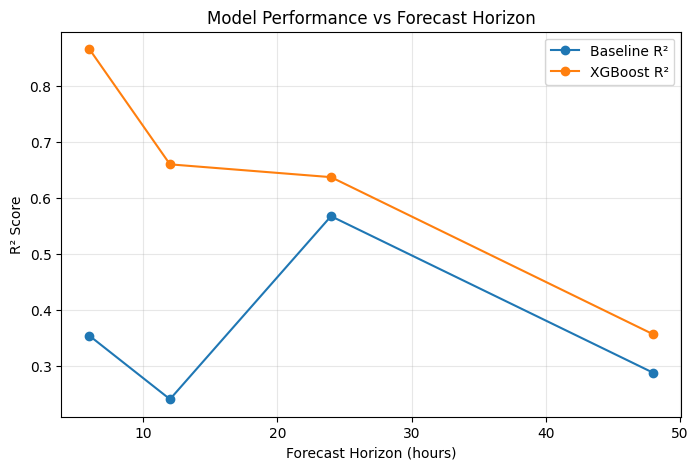

In [47]:
plt.figure(figsize=(8,5))
plt.plot(results_df['horizon_hours'], results_df['baseline_r2'], marker='o', label='Baseline R²')
plt.plot(results_df['horizon_hours'], results_df['xgb_r2'], marker='o', label='XGBoost R²')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('R² Score')
plt.title('Model Performance vs Forecast Horizon')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('horizon_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Categorical accuracy: 85.71%


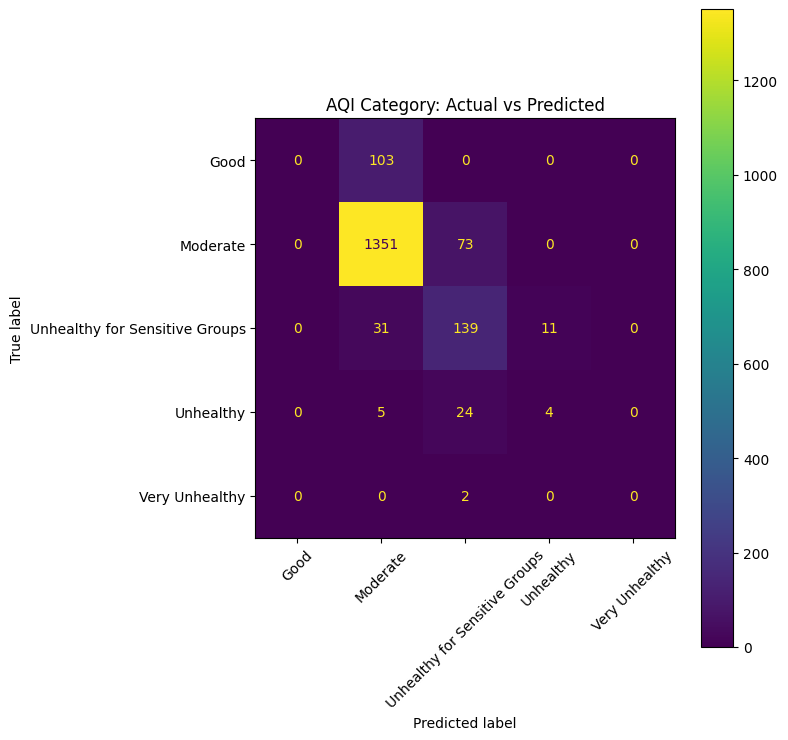

In [48]:
def aqi_to_category(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else: return 'Hazardous'

actual_cat = y_test.apply(aqi_to_category)
pred_cat = pd.Series(xgb_pred, index=y_test.index).apply(aqi_to_category)

categorical_accuracy = (actual_cat == pred_cat).mean()
print(f"Categorical accuracy: {categorical_accuracy:.2%}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cats_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
present_cats = [c for c in cats_order if c in actual_cat.unique() or c in pred_cat.unique()]

cm = confusion_matrix(actual_cat, pred_cat, labels=present_cats)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_cats)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('AQI Category: Actual vs Predicted')
plt.tight_layout()
plt.savefig('aqi_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [49]:
df_primary = df.copy()
df_primary['target'] = df_primary['us_aqi'].shift(-24)
df_primary = df_primary.dropna().reset_index(drop=True)

X_p = df_primary.drop(columns=['time', 'target', 'target_24h'], errors='ignore')
y_p = df_primary['target']

split_idx = int(len(df_p) * 0.8) if False else int(len(df_primary) * 0.8)
X_train_p, X_test_p = X_p.iloc[:split_idx], X_p.iloc[split_idx:]
y_train_p, y_test_p = y_p.iloc[:split_idx], y_p.iloc[split_idx:]

primary_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                              subsample=0.8, colsample_bytree=0.8, random_state=42)
primary_model.fit(X_train_p, y_train_p)

import joblib, json
joblib.dump(primary_model, 'aqi_model_24h.pkl')
with open('feature_columns.json', 'w') as f:
    json.dump(X_p.columns.tolist(), f)